In [1]:
# Instalacja wymaganych pakietów
%pip install -q sentence-transformers transformers pillow sqlalchemy torch numpy pandas

## 1. Inicjalizacja i Konfiguracja

In [2]:
import os
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["USE_TF"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import torch
import numpy as np
from pathlib import Path
from typing import List, Optional, Dict
from dataclasses import dataclass
from datetime import datetime

from sqlalchemy import create_engine, Column, Integer, String, Float, JSON, ForeignKey
from sqlalchemy.orm import declarative_base, sessionmaker, Session, relationship
from sentence_transformers import SentenceTransformer
from transformers import AutoModelForCausalLM, AutoTokenizer

# KONFIGURACJA
EMBEDDING_MODEL = "clip-ViT-B-32"  # Model dla tekstu i obrazów
LLM_MODEL = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
DATABASE_URL = "sqlite:///metal_parts.db"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"✓ Urządzenie: {DEVICE}")
print(f"✓ Baza danych: {DATABASE_URL}")

# BAZA DANYCH
Base = declarative_base()
engine = create_engine(DATABASE_URL, echo=False)
SessionLocal = sessionmaker(bind=engine)

✓ Urządzenie: cpu
✓ Baza danych: sqlite:///metal_parts.db


## 2. Modele Danych

In [3]:
@dataclass
class MetalPart:
    """Reprezentacja części metalowej"""
    part_id: str
    description: str
    material: str
    category: str  # fasteners, bearings, springs, shafts, etc.
    dimensions: Dict  # {"diameter_mm": 8, "length_mm": 20, ...}
    tags: List[str]
    image_path: Optional[str] = None
    image_embedding: Optional[List[float]] = None
    text_embedding: Optional[List[float]] = None


class PartDB(Base):
    """SQLAlchemy model dla bazy części"""
    __tablename__ = "metal_parts"

    id = Column(Integer, primary_key=True, autoincrement=True)
    part_id = Column(String, unique=True, nullable=False)
    description = Column(String, nullable=False)
    material = Column(String, nullable=True)
    category = Column(String, nullable=True)
    dimensions = Column(JSON, nullable=True)  # {"diameter_mm": 8, ...}
    tags = Column(JSON, nullable=True)  # ["śruba", "metalowa", ...]
    image_path = Column(String, nullable=True)
    image_embedding = Column(String, nullable=True)  # jako string
    text_embedding = Column(String, nullable=True)  # jako string
    created_at = Column(String, nullable=True)


class SearchLog(Base):
    """Historia wyszukiwań"""
    __tablename__ = "search_logs"

    id = Column(Integer, primary_key=True, autoincrement=True)
    query = Column(String, nullable=False)
    query_type = Column(String, nullable=False)  # "text", "image", "hybrid"
    top_k = Column(Integer, nullable=True)
    results_count = Column(Integer, nullable=True)
    timestamp = Column(String, nullable=True)

def init_database():
    """Utwórz tabele w bazie"""
    Base.metadata.create_all(engine)
    print("✓ Baza danych zainicjalizowana")

init_database()

✓ Baza danych zainicjalizowana


## 3. Embeddingi i Ekstrakcja Cech

In [4]:
# Załaduj modele embeddingów
print("Ładowanie modelu embeddingów...")
embedding_model = SentenceTransformer(EMBEDDING_MODEL, device=DEVICE)
print(f"✓ Model embeddingów załadowany: {EMBEDDING_MODEL}")

def get_text_embedding(text: str) -> List[float]:
    """Konwertuj tekst na embedding"""
    embedding = embedding_model.encode(text, normalize_embeddings=True)
    return embedding.tolist()


def get_image_embedding(image_path: str) -> List[float]:
    """Konwertuj obraz na embedding"""
    from PIL import Image
    try:
        img = Image.open(image_path).convert('RGB')
        img_embedding = embedding_model.encode(img, normalize_embeddings=True)
        return img_embedding.tolist()
    except Exception as e:
        print(f"✗ Błąd wczytywania obrazu {image_path}: {e}")
        return None


def build_part_text(part: MetalPart) -> str:
    """Zbuduj tekstowy opis części do embeddingu"""
    dims_str = ", ".join([f"{k}: {v}" for k, v in (part.dimensions or {}).items()])
    tags_str = ", ".join(part.tags)

    text = f"""
    Część metalowa: {part.description}
    ID: {part.part_id}
    Kategoria: {part.category}
    Materiał: {part.material}
    Wymiary: {dims_str}
    Tagi: {tags_str}
    """
    return text


# Test
test_text = "Śruba sześciokątna M8 ze stali nierdzewnej"
test_emb = get_text_embedding(test_text)
print(f"\n✓ Test embeddingu tekstowego:")
print(f"  Tekst: {test_text}")
print(f"  Długość embeddingu: {len(test_emb)}D")
print(f"  Pierwsze 5 wartości: {test_emb[:5]}")

Ładowanie modelu embeddingów...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


✓ Model embeddingów załadowany: clip-ViT-B-32

✓ Test embeddingu tekstowego:
  Tekst: Śruba sześciokątna M8 ze stali nierdzewnej
  Długość embeddingu: 512D
  Pierwsze 5 wartości: [-0.015048506669700146, -0.011767561547458172, -0.004894438199698925, -0.006681014318019152, 0.0004227975441608578]


## 4. Funkcje do Indeksowania Części

In [5]:
def add_part_to_db(db: Session, part: MetalPart) -> bool:
    """Dodaj część do bazy danych z embeddingami"""
    try:
        # Generuj embeddingi
        text_desc = build_part_text(part)
        text_emb = get_text_embedding(text_desc)

        image_emb = None
        if part.image_path and Path(part.image_path).exists():
            image_emb = get_image_embedding(part.image_path)

        # Konwertuj embedding na string dla SQLite
        text_emb_str = ";".join(str(x) for x in text_emb) if text_emb else None
        image_emb_str = ";".join(str(x) for x in image_emb) if image_emb else None

        # Zapisz do bazy
        db_part = PartDB(
            part_id=part.part_id,
            description=part.description,
            material=part.material,
            category=part.category,
            dimensions=part.dimensions,
            tags=part.tags,
            image_path=part.image_path,
            text_embedding=text_emb_str,
            image_embedding=image_emb_str,
            created_at=datetime.now().isoformat()
        )
        db.add(db_part)
        db.commit()
        return True
    except Exception as e:
        print(f"✗ Błąd dodawania części: {e}")
        return False


def load_parts_from_db(db: Session) -> List[PartDB]:
    """Załaduj wszystkie części z bazy"""
    return db.query(PartDB).all()


def parse_embedding_from_db(emb_str: str) -> List[float]:
    """Konwertuj string embeddingu ze stanu do listy"""
    if not emb_str:
        return None
    return [float(x) for x in emb_str.split(";")]


def cosine_similarity(a: List[float], b: List[float]) -> float:
    """Oblicz cosine similarity między dwoma wektorami"""
    a = np.array(a)
    b = np.array(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)

print("✓ Funkcje indeksowania załadowane")

✓ Funkcje indeksowania załadowane


## 5. Retriever - Wyszukiwanie Podobnych Części

In [6]:
def search_parts_by_text(db: Session, query: str, top_k: int = 5, category_filter: Optional[str] = None) -> List[tuple]:
    """
    Wyszukaj części na podstawie tekstu (opis, materiał, tagi)
    Zwraca: [(część, similarity_score), ...]
    """
    # Zkonwertuj zapytanie na embedding
    query_emb = get_text_embedding(query)

    # Załaduj wszystkie części z bazy
    all_parts = load_parts_from_db(db)

    # Oblicz similarity
    results = []
    for part in all_parts:
        # Filtr po kategorii
        if category_filter and part.category != category_filter:
            continue

        # Pobierz embedding
        part_emb = parse_embedding_from_db(part.text_embedding)
        if not part_emb:
            continue

        # Oblicz similarity
        score = cosine_similarity(query_emb, part_emb)
        results.append((part, score))

    # Sortuj i zwróć top-k
    results.sort(key=lambda x: x[1], reverse=True)
    return results[:top_k]


def search_parts_by_image(db: Session, image_path: str, top_k: int = 5, category_filter: Optional[str] = None) -> List[tuple]:
    """
    Wyszukaj części na podstawie obrazu
    """
    # Zkonwertuj obraz na embedding
    query_emb = get_image_embedding(image_path)
    if not query_emb:
        return []

    # Załaduj wszystkie części
    all_parts = load_parts_from_db(db)

    # Oblicz similarity
    results = []
    for part in all_parts:
        if category_filter and part.category != category_filter:
            continue

        part_emb = parse_embedding_from_db(part.image_embedding)
        if not part_emb:
            continue

        score = cosine_similarity(query_emb, part_emb)
        results.append((part, score))

    results.sort(key=lambda x: x[1], reverse=True)
    return results[:top_k]


def search_parts_hybrid(db: Session, text_query: str, image_path: Optional[str] = None,
                       top_k: int = 5, category_filter: Optional[str] = None) -> List[tuple]:
    """
    Wyszukaj części hybrydowo (tekst + obraz)
    Kombinuje wyniki z wyszukiwania tekstowego i obrazowego
    """
    text_results = search_parts_by_text(db, text_query, top_k=top_k*2, category_filter=category_filter)

    if image_path and Path(image_path).exists():
        image_results = search_parts_by_image(db, image_path, top_k=top_k*2, category_filter=category_filter)

        # Połącz wyniki (średnia z obu wyszukiwań)
        combined = {}
        for part, score in text_results:
            combined[part.id] = {"part": part, "score": score * 0.6}  # 60% wagi dla tekstu

        for part, score in image_results:
            if part.id in combined:
                combined[part.id]["score"] += score * 0.4  # 40% wagi dla obrazu
            else:
                combined[part.id] = {"part": part, "score": score * 0.4}

        results = [(v["part"], v["score"]) for v in combined.values()]
    else:
        results = text_results

    results.sort(key=lambda x: x[1], reverse=True)
    return results[:top_k]

print("✓ Retriever załadowany")

✓ Retriever załadowany


## 6. LLM - Generacja Raportu

In [7]:
# Załaduj LLM
print("Ładowanie modelu LLM...")
try:
    tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL)
    llm_model = AutoModelForCausalLM.from_pretrained(LLM_MODEL, low_cpu_mem_usage=True)
    llm_model.to(DEVICE)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    print(f"✓ LLM załadowany: {LLM_MODEL}")
except Exception as e:
    print(f"✗ Błąd ładowania LLM: {e}")
    llm_model = None
    tokenizer = None


def generate_report(results: List[tuple], query: str) -> str:
    """
    Wygeneruj raport o znalezionych częściach za pomocą LLM
    """
    if not llm_model or not tokenizer:
        # Fallback: zwróć prosty raport tekstowy
        return generate_simple_report(results, query)

    # Zbuduj kontekst
    context = "\n\n".join([
        f"Część {i+1}:\n"
        f"  ID: {part.part_id}\n"
        f"  Opis: {part.description}\n"
        f"  Materiał: {part.material}\n"
        f"  Kategoria: {part.category}\n"
        f"  Wymiary: {part.dimensions}\n"
        f"  Tagi: {', '.join(part.tags or [])}\n"
        f"  Dopasowanie: {score*100:.1f}%"
        for i, (part, score) in enumerate(results)
    ])

    prompt = f"""
    Użytkownik szuka części metalowych. Zapytanie: "{query}"

    Znalezione części:
    {context}

    Na podstawie wyników wyszukiwania, wygeneruj krótki, rzeczowy raport o znalezionych częściach.
    Wskaż, które części najlepiej pasują do zapytania i dlaczego.
    """

    # Tokenizuj i wygeneruj
    inputs = tokenizer(prompt, return_tensors="pt", max_length=512, truncation=True).to(DEVICE)

    with torch.no_grad():
        outputs = llm_model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return response.split("Na podstawie wyników")[-1].strip() if "Na podstawie wyników" in response else response


def generate_simple_report(results: List[tuple], query: str) -> str:
    """
    Fallback: prosty raport tekstowy bez LLM
    """
    report = f"RAPORT WYSZUKIWANIA\n"
    report += f"Zapytanie: {query}\n"
    report += f"Znaleziono: {len(results)} części\n"
    report += "\n" + "="*60 + "\n\n"

    for i, (part, score) in enumerate(results, 1):
        report += f"#{i} (Dopasowanie: {score*100:.1f}%)\n"
        report += f"  ID: {part.part_id}\n"
        report += f"  Opis: {part.description}\n"
        report += f"  Materiał: {part.material}\n"
        report += f"  Kategoria: {part.category}\n"
        if part.dimensions:
            report += f"  Wymiary: {part.dimensions}\n"
        if part.tags:
            report += f"  Tagi: {', '.join(part.tags)}\n"
        report += "\n"

    return report

print("✓ Funkcje generacji raportu załadowane")

Ładowanie modelu LLM...
✓ LLM załadowany: TinyLlama/TinyLlama-1.1B-Chat-v1.0
✓ Funkcje generacji raportu załadowane


## 7. Główna Funkcja RAG

In [8]:
def rag_search_metal_parts(query: str, query_type: str = "text", image_path: Optional[str] = None,
                          category_filter: Optional[str] = None, top_k: int = 5) -> Dict:
    """
    Główna funkcja RAG do wyszukiwania części metalowych

    Args:
        query: Tekstowe zapytanie lub opis części
        query_type: "text", "image", lub "hybrid"
        image_path: Ścieżka do obrazu (jeśli query_type="image" lub "hybrid")
        category_filter: Filtruj po kategorii (np. "fasteners")
        top_k: Ile części zwrócić

    Returns:
        {
            "query": str,
            "results": [(part_dict, score), ...],
            "report": str,
            "timestamp": str
        }
    """
    with SessionLocal() as db:
        # Wyszukiwanie
        if query_type == "text":
            results = search_parts_by_text(db, query, top_k=top_k, category_filter=category_filter)
        elif query_type == "image":
            results = search_parts_by_image(db, image_path, top_k=top_k, category_filter=category_filter)
        elif query_type == "hybrid":
            results = search_parts_hybrid(db, query, image_path=image_path, top_k=top_k, category_filter=category_filter)
        else:
            return {"error": f"Nieznany typ wyszukiwania: {query_type}"}

        # Konwertuj części na słowniki
        results_dicts = [
            ({
                "part_id": part.part_id,
                "description": part.description,
                "material": part.material,
                "category": part.category,
                "dimensions": part.dimensions,
                "tags": part.tags
            }, score)
            for part, score in results
        ]

        # Wygeneruj raport
        report = generate_simple_report(results, query)

        # Zapisz do logu
        log = SearchLog(
            query=query,
            query_type=query_type,
            top_k=top_k,
            results_count=len(results),
            timestamp=datetime.now().isoformat()
        )
        db.add(log)
        db.commit()

        return {
            "query": query,
            "query_type": query_type,
            "results": results_dicts,
            "report": report,
            "timestamp": datetime.now().isoformat()
        }

print("✓ Główna funkcja RAG załadowana")

✓ Główna funkcja RAG załadowana


## 8. Przykładowe Dane i Test

In [9]:
# Syntetyczne dane części metalowych z obrazami z katalogu metal/
SAMPLE_PARTS = [
    MetalPart(
        part_id="SCR-M8-1.25-20",
        description="Śruba sześciokątna M8 ze stali nierdzewnej",
        material="Stal nierdzewna A2-70",
        category="fasteners",
        dimensions={"diameter_mm": 8.0, "length_mm": 20.0, "pitch_mm": 1.25},
        tags=["śruba", "metalowa", "nierdzewna", "heksagonalna", "M8"],
        image_path="obrazy/metal/m1.jpg"
    ),
    MetalPart(
        part_id="SCR-M6-1.0-16",
        description="Śruba sześciokątna M6 ze stali zwykłej",
        material="Stal zwykła ocynkowana",
        category="fasteners",
        dimensions={"diameter_mm": 6.0, "length_mm": 16.0, "pitch_mm": 1.0},
        tags=["śruba", "metalowa", "ocynkowana", "heksagonalna", "M6"],
        image_path="obrazy/metal/m2.webp"
    ),
    MetalPart(
        part_id="BRG-6205-2RS",
        description="Łożysko kulkowe 6205-2RS",
        material="Stal chromowa",
        category="bearings",
        dimensions={"bore_mm": 25.0, "outer_mm": 52.0, "width_mm": 15.0},
        tags=["łożysko", "kulkowe", "metalowe", "6205"],
        image_path="obrazy/metal/m3.jpg"
    ),
    MetalPart(
        part_id="SHF-12mm-300mm",
        description="Wał stalowy chromowany 12mm x 300mm",
        material="Stal chromowana",
        category="shafts",
        dimensions={"diameter_mm": 12.0, "length_mm": 300.0},
        tags=["wał", "stalowy", "chromowany", "okrągły"],
        image_path="obrazy/metal/m4.jpg"
    ),
    MetalPart(
        part_id="SPN-1.2mm-500mm",
        description="Sprężyna naciągowa ze stali nierdzewnej",
        material="Stal nierdzewna A2-70",
        category="springs",
        dimensions={"wire_diameter_mm": 1.2, "free_length_mm": 500.0},
        tags=["sprężyna", "naciągowa", "nierdzewna", "metalowa"],
        image_path="obrazy/metal/m5.webp"
    ),
    MetalPart(
        part_id="BOLT-M10-30",
        description="Śruba z łbem sześciokątnym M10",
        material="Stal nierdzewna A4-80",
        category="fasteners",
        dimensions={"diameter_mm": 10.0, "length_mm": 30.0},
        tags=["śruba", "metalowa", "nierdzewna", "M10"],
        image_path="obrazy/metal/m6.webp"
    ),
    MetalPart(
        part_id="GEAR-20T-8mm",
        description="Koło zębate 20 zębów, otwór 8mm",
        material="Stal hartowana",
        category="gears",
        dimensions={"teeth": 20, "bore_mm": 8.0, "module": 1.0},
        tags=["koło", "zębate", "metalowe", "przekładnia"],
        image_path="obrazy/metal/m7.jpg"
    )
]

# Dodaj przykładowe dane do bazy
with SessionLocal() as db:
    # Sprawdź, czy baza jest pusta
    existing = db.query(PartDB).count()
    if existing == 0:
        print(f"Dodawanie {len(SAMPLE_PARTS)} części do bazy...")
        for part in SAMPLE_PARTS:
            success = add_part_to_db(db, part)
            if success:
                print(f"  ✓ {part.part_id}: {part.description} (obraz: {part.image_path})")
        print(f"\n✓ Wszystkie przykładowe części dodane z obrazami")
    else:
        print(f"✓ Baza zawiera już {existing} części")

✓ Baza zawiera już 7 części


## 9. Testy Wyszukiwania RAG

In [10]:
# Re-index all parts with current embedding model to fix dimension mismatch
print("Ponowne indeksowanie części z aktualnym modelem embeddingów...")
with SessionLocal() as db:
    # Delete all existing parts
    db.query(PartDB).delete()
    db.commit()

    # Re-add all sample parts
    for part in SAMPLE_PARTS:
        success = add_part_to_db(db, part)
        if success:
            print(f"  ✓ Re-indexed: {part.part_id}")
    print("✓ Wszystkie części ponownie zaindeksowane\n")

# Test 1: Wyszukiwanie tekstowe
print("\n" + "="*70)
print("TEST 1: Wyszukiwanie tekstowe")
print("="*70)

result1 = rag_search_metal_parts(
    query="Szukam śruby metalowej do połączenia części",
    query_type="text",
    top_k=3
)

print(f"\nQuery: {result1['query']}")
print(f"Typ: {result1['query_type']}")
print(f"\nRaport:\n{result1['report']}")

Ponowne indeksowanie części z aktualnym modelem embeddingów...
  ✓ Re-indexed: SCR-M8-1.25-20
  ✓ Re-indexed: SCR-M6-1.0-16
  ✓ Re-indexed: BRG-6205-2RS
  ✓ Re-indexed: SHF-12mm-300mm
  ✓ Re-indexed: SPN-1.2mm-500mm
  ✓ Re-indexed: BOLT-M10-30
  ✓ Re-indexed: GEAR-20T-8mm
✓ Wszystkie części ponownie zaindeksowane


TEST 1: Wyszukiwanie tekstowe

Query: Szukam śruby metalowej do połączenia części
Typ: text

Raport:
RAPORT WYSZUKIWANIA
Zapytanie: Szukam śruby metalowej do połączenia części
Znaleziono: 3 części


#1 (Dopasowanie: 79.4%)
  ID: SPN-1.2mm-500mm
  Opis: Sprężyna naciągowa ze stali nierdzewnej
  Materiał: Stal nierdzewna A2-70
  Kategoria: springs
  Wymiary: {'wire_diameter_mm': 1.2, 'free_length_mm': 500.0}
  Tagi: sprężyna, naciągowa, nierdzewna, metalowa

#2 (Dopasowanie: 78.6%)
  ID: SCR-M6-1.0-16
  Opis: Śruba sześciokątna M6 ze stali zwykłej
  Materiał: Stal zwykła ocynkowana
  Kategoria: fasteners
  Wymiary: {'diameter_mm': 6.0, 'length_mm': 16.0, 'pitch_mm': 1.0}
  Tag

In [11]:
# Test 2: Wyszukiwanie ze filtrem kategorii
print("\n" + "="*70)
print("TEST 2: Wyszukiwanie ze filtrem kategorii (bearings)")
print("="*70)

result2 = rag_search_metal_parts(
    query="Łożysko do maszyny obrotowej",
    query_type="text",
    category_filter="bearings",
    top_k=2
)

print(f"\nQuery: {result2['query']}")
print(f"Filtr kategorii: bearings")
print(f"\nRaport:\n{result2['report']}")


TEST 2: Wyszukiwanie ze filtrem kategorii (bearings)

Query: Łożysko do maszyny obrotowej
Filtr kategorii: bearings

Raport:
RAPORT WYSZUKIWANIA
Zapytanie: Łożysko do maszyny obrotowej
Znaleziono: 1 części


#1 (Dopasowanie: 70.7%)
  ID: BRG-6205-2RS
  Opis: Łożysko kulkowe 6205-2RS
  Materiał: Stal chromowa
  Kategoria: bearings
  Wymiary: {'bore_mm': 25.0, 'outer_mm': 52.0, 'width_mm': 15.0}
  Tagi: łożysko, kulkowe, metalowe, 6205




In [12]:
# Test 3: Wyszukiwanie po konkretnych wymiarach
print("\n" + "="*70)
print("TEST 3: Wyszukiwanie po wymiarach")
print("="*70)

result3 = rag_search_metal_parts(
    query="Wał o średnicy 12mm ze stali chromowanej",
    query_type="text",
    top_k=3
)

print(f"\nQuery: {result3['query']}")
print(f"\nRaport:\n{result3['report']}")


TEST 3: Wyszukiwanie po wymiarach

Query: Wał o średnicy 12mm ze stali chromowanej

Raport:
RAPORT WYSZUKIWANIA
Zapytanie: Wał o średnicy 12mm ze stali chromowanej
Znaleziono: 3 części


#1 (Dopasowanie: 77.3%)
  ID: SPN-1.2mm-500mm
  Opis: Sprężyna naciągowa ze stali nierdzewnej
  Materiał: Stal nierdzewna A2-70
  Kategoria: springs
  Wymiary: {'wire_diameter_mm': 1.2, 'free_length_mm': 500.0}
  Tagi: sprężyna, naciągowa, nierdzewna, metalowa

#2 (Dopasowanie: 74.6%)
  ID: SCR-M6-1.0-16
  Opis: Śruba sześciokątna M6 ze stali zwykłej
  Materiał: Stal zwykła ocynkowana
  Kategoria: fasteners
  Wymiary: {'diameter_mm': 6.0, 'length_mm': 16.0, 'pitch_mm': 1.0}
  Tagi: śruba, metalowa, ocynkowana, heksagonalna, M6

#3 (Dopasowanie: 73.8%)
  ID: SHF-12mm-300mm
  Opis: Wał stalowy chromowany 12mm x 300mm
  Materiał: Stal chromowana
  Kategoria: shafts
  Wymiary: {'diameter_mm': 12.0, 'length_mm': 300.0}
  Tagi: wał, stalowy, chromowany, okrągły





TEST 6: Wyświetlanie obrazów znalezionych części


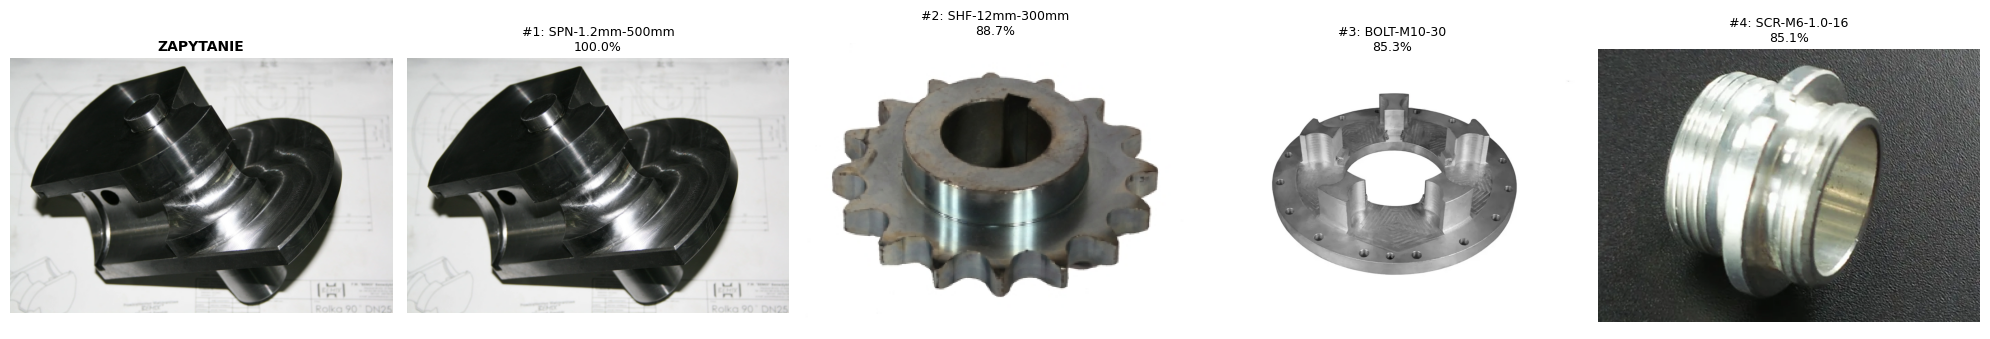


✓ Wyświetlono obraz zapytania i 4 najbardziej podobnych części


In [13]:
# Test 6: Wizualizacja wyników wyszukiwania obrazowego
print("\n" + "="*70)
print("TEST 6: Wyświetlanie obrazów znalezionych części")
print("="*70)

from PIL import Image
import matplotlib.pyplot as plt

# Wyszukaj części na podstawie obrazu
test_image3 = "obrazy/metal/m5.webp"
result6 = rag_search_metal_parts(
    query="Część z obrazu",
    query_type="image",
    image_path=test_image3,
    top_k=4
)

# Wyświetl obraz zapytania i wyniki
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Obraz zapytania
if Path(test_image3).exists():
    axes[0].imshow(Image.open(test_image3))
    axes[0].set_title("ZAPYTANIE", fontsize=10, fontweight='bold')
else:
    axes[0].text(0.5, 0.5, "Obraz zapytania\nnie znaleziono", horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes)
    axes[0].set_title("ZAPYTANIE", fontsize=10, fontweight='bold')
axes[0].axis('off')

# Wyniki
with SessionLocal() as db:
    for idx, (part_dict, score) in enumerate(result6['results'][:4]):
        # Znajdź pełne dane części z bazy
        part_db = db.query(PartDB).filter_by(part_id=part_dict['part_id']).first()
        if part_db and part_db.image_path and Path(part_db.image_path).exists():
            img = Image.open(part_db.image_path)
            axes[idx+1].imshow(img)
            axes[idx+1].set_title(f"#{idx+1}: {part_dict['part_id']}\n{score*100:.1f}%",
                                 fontsize=9)
            axes[idx+1].axis('off')

plt.tight_layout()
plt.show()

print(f"\n✓ Wyświetlono obraz zapytania i {len(result6['results'])} najbardziej podobnych części")

In [14]:
# Test 5: Wyszukiwanie hybrydowe (tekst + obraz)
print("\n" + "="*70)
print("TEST 5: Wyszukiwanie hybrydowe (tekst + obraz)")
print("="*70)

test_image2 = "obrazy/metal/m3.jpg"
print(f"Wyszukiwanie: tekst + obraz ({test_image2})")

result5 = rag_search_metal_parts(
    query="Łożysko kulkowe do maszyny przemysłowej",
    query_type="hybrid",
    image_path=test_image2,
    top_k=3
)

print(f"\nQuery: {result5['query']}")
print(f"Typ: {result5['query_type']}")
print(f"Obraz zapytania: {test_image2}")
print(f"\nRaport:\n{result5['report']}")



TEST 5: Wyszukiwanie hybrydowe (tekst + obraz)
Wyszukiwanie: tekst + obraz (obrazy/metal/m3.jpg)

Query: Łożysko kulkowe do maszyny przemysłowej
Typ: hybrid
Obraz zapytania: obrazy/metal/m3.jpg

Raport:
RAPORT WYSZUKIWANIA
Zapytanie: Łożysko kulkowe do maszyny przemysłowej
Znaleziono: 3 części


#1 (Dopasowanie: 81.9%)
  ID: BRG-6205-2RS
  Opis: Łożysko kulkowe 6205-2RS
  Materiał: Stal chromowa
  Kategoria: bearings
  Wymiary: {'bore_mm': 25.0, 'outer_mm': 52.0, 'width_mm': 15.0}
  Tagi: łożysko, kulkowe, metalowe, 6205

#2 (Dopasowanie: 79.7%)
  ID: SPN-1.2mm-500mm
  Opis: Sprężyna naciągowa ze stali nierdzewnej
  Materiał: Stal nierdzewna A2-70
  Kategoria: springs
  Wymiary: {'wire_diameter_mm': 1.2, 'free_length_mm': 500.0}
  Tagi: sprężyna, naciągowa, nierdzewna, metalowa

#3 (Dopasowanie: 78.1%)
  ID: SHF-12mm-300mm
  Opis: Wał stalowy chromowany 12mm x 300mm
  Materiał: Stal chromowana
  Kategoria: shafts
  Wymiary: {'diameter_mm': 12.0, 'length_mm': 300.0}
  Tagi: wał, stalow

In [15]:
# Test 4: Wyszukiwanie na podstawie obrazu dla wszystkich obrazów w folderze 'metal'
print("\n" + "="*70)
print("TEST 4: Wyszukiwanie na podstawie obrazu (dla wszystkich obrazów)")
print("="*70)

import glob

# Użyj wszystkich obrazów z katalogu obrazy/metal jako zapytanie
image_files = glob.glob("obrazy/metal/*.jpg") + glob.glob("obrazy/metal/*.webp")

if not image_files:
    print("Brak plików obrazów w katalogu 'obrazy/metal'. Upewnij się, że obrazy są przesłane.")
else:
    for test_image in image_files:
        print(f"\nWyszukiwanie podobnych części do obrazu: {test_image}")

        result4 = rag_search_metal_parts(
            query="Część metalowa z obrazu",
            query_type="image",
            image_path=test_image,
            top_k=3
        )

        print(f"\nQuery: {result4['query']}")
        print(f"Typ: {result4['query_type']}")
        print(f"Obraz zapytania: {test_image}")
        print(f"\nRaport:\n{result4['report']}")

        # Optional: Display the results for each image if needed (similar to Test 6)
        # from PIL import Image
        # import matplotlib.pyplot as plt
        #
        # fig, axes = plt.subplots(1, min(4, len(result4['results'])) + 1, figsize=(20, 4))
        # if Path(test_image).exists():
        #     axes[0].imshow(Image.open(test_image))
        #     axes[0].set_title("ZAPYTANIE", fontsize=10, fontweight='bold')
        # else:
        #     axes[0].text(0.5, 0.5, "Obraz zapytania\nnie znaleziono", horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes)
        #     axes[0].set_title("ZAPYTANIE", fontsize=10, fontweight='bold')
        # axes[0].axis('off')
        #
        # with SessionLocal() as db:
        #     for idx, (part_dict, score) in enumerate(result4['results'][:3]):
        #         part_db = db.query(PartDB).filter_by(part_id=part_dict['part_id']).first()
        #         if part_db and part_db.image_path and Path(part_db.image_path).exists():
        #             img = Image.open(part_db.image_path)
        #             axes[idx+1].imshow(img)
        #             axes[idx+1].set_title(f"#{idx+1}: {part_dict['part_id']}\n{score*100:.1f}%",
        #                                  fontsize=9)
        #             axes[idx+1].axis('off')
        # plt.tight_layout()
        # plt.show()


TEST 4: Wyszukiwanie na podstawie obrazu (dla wszystkich obrazów)

Wyszukiwanie podobnych części do obrazu: obrazy/metal/m1.jpg

Query: Część metalowa z obrazu
Typ: image
Obraz zapytania: obrazy/metal/m1.jpg

Raport:
RAPORT WYSZUKIWANIA
Zapytanie: Część metalowa z obrazu
Znaleziono: 3 części


#1 (Dopasowanie: 100.0%)
  ID: SCR-M8-1.25-20
  Opis: Śruba sześciokątna M8 ze stali nierdzewnej
  Materiał: Stal nierdzewna A2-70
  Kategoria: fasteners
  Wymiary: {'diameter_mm': 8.0, 'length_mm': 20.0, 'pitch_mm': 1.25}
  Tagi: śruba, metalowa, nierdzewna, heksagonalna, M8

#2 (Dopasowanie: 81.9%)
  ID: GEAR-20T-8mm
  Opis: Koło zębate 20 zębów, otwór 8mm
  Materiał: Stal hartowana
  Kategoria: gears
  Wymiary: {'teeth': 20, 'bore_mm': 8.0, 'module': 1.0}
  Tagi: koło, zębate, metalowe, przekładnia

#3 (Dopasowanie: 81.6%)
  ID: SCR-M6-1.0-16
  Opis: Śruba sześciokątna M6 ze stali zwykłej
  Materiał: Stal zwykła ocynkowana
  Kategoria: fasteners
  Wymiary: {'diameter_mm': 6.0, 'length_mm': 16

## Test 4: Wyszukiwanie na podstawie obrazu

## 10. Statystyki i Podsumowanie

In [16]:
# Wyświetl statystyki bazy
with SessionLocal() as db:
    total_parts = db.query(PartDB).count()
    by_category = {}
    for part in db.query(PartDB).all():
        cat = part.category or "unknown"
        by_category[cat] = by_category.get(cat, 0) + 1

    search_logs = db.query(SearchLog).all()

    print("\n" + "="*70)
    print("STATYSTYKI BAZY DANYCH")
    print("="*70)
    print(f"Łączna liczba części: {total_parts}")
    print(f"\nPodzielenie po kategoriach:")
    for cat, count in by_category.items():
        print(f"  - {cat}: {count}")
    print(f"\nLiczba przeprowadzonych wyszukiwań: {len(search_logs)}")

    if search_logs:
        print(f"\nOstatnie wyszukiwania:")
        for log in search_logs[-5:]:
            print(f"  - {log.query_type}: '{log.query}' → {log.results_count} wyników")


STATYSTYKI BAZY DANYCH
Łączna liczba części: 7

Podzielenie po kategoriach:
  - fasteners: 3
  - bearings: 1
  - shafts: 1
  - springs: 1
  - gears: 1

Liczba przeprowadzonych wyszukiwań: 66

Ostatnie wyszukiwania:
  - image: 'Część metalowa z obrazu' → 3 wyników
  - image: 'Część metalowa z obrazu' → 3 wyników
  - image: 'Część metalowa z obrazu' → 3 wyników
  - image: 'Część metalowa z obrazu' → 3 wyników
  - image: 'Część metalowa z obrazu' → 3 wyników
